# 15 — Dataset evidence: real BOAMP vs the v0.4 synthetic benchmark

## What this notebook is

The project rests on two datasets. The **real prepared BOAMP corpus** (84,623
notices, Pays de la Loire, 2015-01 → 2026-07) is what every substantive claim is
ultimately about. The **v0.4 synthetic benchmark** exists to answer one question
the real corpus cannot: whether a linkage algorithm recovers *known* recurrence
relations, since BOAMP contains no legal-renewal ground truth.

This notebook is the evidence dashboard for both. It shows where the synthetic
corpus reproduces real structure and — with equal prominence — **where it does
not**, because the failures are what bound the claims we are allowed to make.

Every figure is written to `reports/figures/dataset_evidence/`.

## Reading guide

Sections 1–5 compare observable structure. Section 6 compares the four features
the linkage rule actually scores, which is where synthetic-to-real transfer
lives or dies. Section 7 covers the candidate environment. Sections 8–9 are
real-only: the survival evidence and the selection bias that governs it.

Colours are fixed throughout: **blue = real BOAMP**, **orange = synthetic v0.4**.


## 0. Setup

In [1]:
import sys, glob, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

FIG = ROOT / "reports" / "figures" / "dataset_evidence"
FIG.mkdir(parents=True, exist_ok=True)

# Dataset identity is categorical: slots 1-3 of the validated reference palette,
# used unchanged and in fixed order. These three validate on the all-pairs
# pairlist in both modes, which is what the scatter/ECDF forms here require.
REAL, V4, V3 = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#b8b7b1"

# The three linkage rules are ORDERED by acceptance threshold
# (strict 0.442 > balanced 0.343 > broad 0.278), so they are a magnitude
# encoding, not an identity one: one hue, light -> dark, never three hues.
RULE_RAMP = ["#8ab8e8", "#2a78d6", "#17427a"]

mpl.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": MUTED, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": "#e8e8e5", "grid.linewidth": 0.7,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 11, "axes.titleweight": "semibold", "axes.labelsize": 9.5,
    "axes.labelcolor": INK2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "xtick.color": INK2, "ytick.color": INK2, "legend.fontsize": 9,
    "legend.frameon": False, "font.size": 9.5, "text.color": INK,
})

def finish(fig, name):
    """Save both formats and return the figure for inline display."""
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")
    return fig

def ecdf(ax, values, label, color, lw=2.0):
    v = np.sort(pd.Series(values).dropna().to_numpy())
    if len(v) == 0:
        return
    y = np.arange(1, len(v) + 1) / len(v)
    ax.plot(v, y, color=color, lw=lw, label=label, solid_capstyle="round")

def norm_cpv(series):
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""].str.replace(r"\.0$", "", regex=True)
    s = s[s.str.match(r"^[0-9]+$")]
    return s.str.zfill(8)

print("setup ok")

setup ok


In [2]:
# ---- real prepared corpus -------------------------------------------------
real = pd.read_csv(ROOT / "data/interim/boamp_common_prepared.csv", low_memory=False)
real["publication_date"] = pd.to_datetime(real["publication_date"], errors="coerce")
real["publication_year"] = real["publication_date"].dt.year

# ---- synthetic benchmarks, both released versions -------------------------
V4_VERSION = "v0_4_population_alias_revision"
V3_VERSION = "v0_3_temporal_candidate_revision"
SYN_VERSION = V4_VERSION            # the current version, kept for later cells
SYN_WORLDS = ["001", "002", "003"]

def load_world(version, world):
    base = ROOT / "data/processed/synthetic_benchmark" / version / "central_provisional"
    p = glob.glob(str(base / f"world_{world}/corruption_*/observed_notices.parquet"))[0]
    d = pd.read_parquet(p)
    d["publication_date"] = pd.to_datetime(d["publication_date"], errors="coerce")
    d["publication_year"] = d["publication_date"].dt.year
    d["world"] = world
    return d

v4_worlds = {w: load_world(V4_VERSION, w) for w in SYN_WORLDS}
v3_worlds = {w: load_world(V3_VERSION, w) for w in SYN_WORLDS}
syn = v4_worlds["001"]              # reference world for like-for-like shapes
v3 = v3_worlds["001"]

# Fixed order used by every figure: real is the reference, then chronological.
DATASETS = [("real BOAMP", real, REAL), ("synthetic v0.3", v3, V3), ("synthetic v0.4", syn, V4)]

print(f"real       : {len(real):,} notices, {real.publication_year.min():.0f}-{real.publication_year.max():.0f}")
for lab, ws in [("v0.3", v3_worlds), ("v0.4", v4_worlds)]:
    for w, d in ws.items():
        print(f"{lab} world {w}: {len(d):,} notices")

real       : 84,623 notices, 2015-2026
v0.3 world 001: 87,360 notices
v0.3 world 002: 87,639 notices
v0.3 world 003: 83,911 notices
v0.4 world 001: 82,278 notices
v0.4 world 002: 84,451 notices
v0.4 world 003: 83,969 notices


## 1. Headline comparison

A single table before any plot, so the rest of the notebook has a reference
frame.

In [3]:
def buyer_keys(df):
    if "buyer_key" in df.columns:
        return df["buyer_key"]
    return df["buyer_siret_raw"].fillna(df["buyer_siren_raw"]).fillna(df["buyer_name_raw"])

rows = []
for label, df, _c in DATASETS:
    keys = buyer_keys(df)
    cpv = norm_cpv(df["cpv_clean"])
    text = df["objet_clean"].fillna("").astype(str)
    rows.append({
        "dataset": label,
        "notices": len(df),
        "distinct buyer keys": keys.nunique(),
        "buyer keys per notice": keys.nunique() / len(df),
        "top-10 buyer share": keys.value_counts().head(10).sum() / len(df),
        "CPV present": df["cpv_clean"].notna().mean(),
        "distinct CPV codes": cpv.nunique(),
        "notices per CPV code": len(cpv) / max(cpv.nunique(), 1),
        "median text length": text.str.len().median(),
        "exact duplicate text": text.duplicated(keep=False).mean(),
    })
overview = pd.DataFrame(rows).set_index("dataset").T
overview.style.format(precision=4)

dataset,real BOAMP,synthetic v0.3,synthetic v0.4
notices,84623.0000,87360.0000,82278.0000
distinct buyer keys,5268.0000,11507.0000,4042.0000
buyer keys per notice,0.0623,0.1317,0.0491
top-10 buyer share,0.1554,0.1061,0.1476
CPV present,0.8294,0.8495,0.8480
distinct CPV codes,3145.0000,41541.0000,39126.0000
notices per CPV code,22.3164,1.7865,1.7833
median text length,98.0000,95.0000,94.0000
exact duplicate text,0.5143,0.4514,0.4988


## 2. Corpus composition

The question is whether the synthetic corpus sits in the same place as the real
one on the coarse descriptors: when notices were published, what kind they are,
which schema produced them, and which CPV divisions they fall in.

Publication year is change-over-time, so it gets a line. The other three are
identity comparisons across a handful of categories, so they get grouped
horizontal bars.

findfont: Failed to find font weight semibold, now using 700.


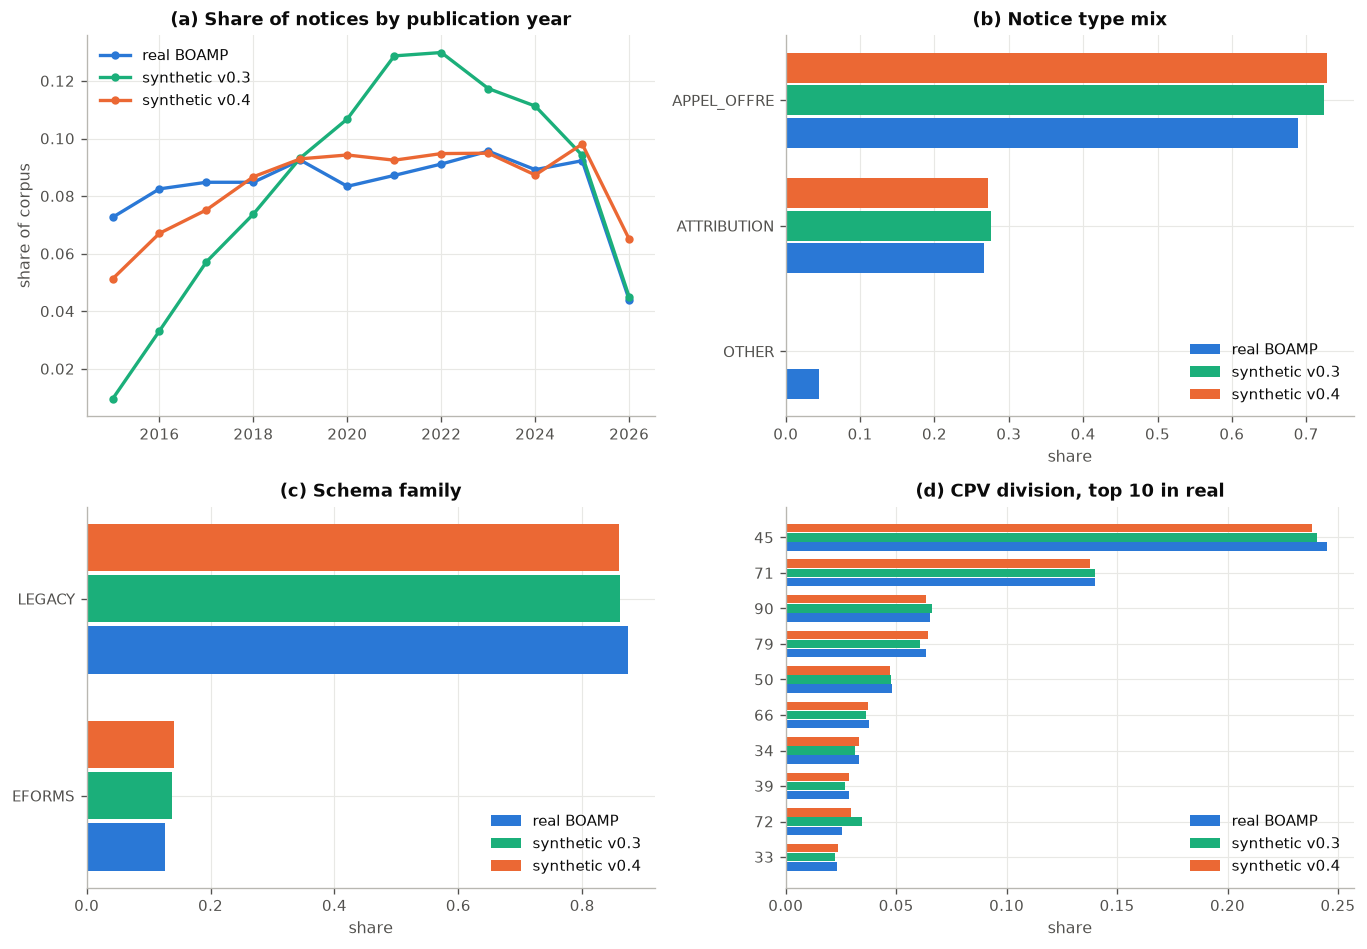

synthetic v0.3 vs real  -  TV publication year 0.1511   TV CPV division 0.0247
synthetic v0.4 vs real  -  TV publication year 0.0490   TV CPV division 0.0173


In [4]:
def shares(df, col, top=None):
    s = df[col].astype(str).replace({"nan": "missing"}).value_counts(normalize=True)
    return s.head(top) if top else s

def grouped_barh(ax, cats, series, title, xlabel="share"):
    """One horizontal bar per dataset per category, in fixed dataset order."""
    y = np.arange(len(cats)); h = 0.26
    offsets = [h, 0.0, -h]
    for (label, values, color), off in zip(series, offsets):
        ax.barh(y + off, values, h * 0.92, color=color, label=label)
    ax.set_yticks(y); ax.set_yticklabels(cats); ax.invert_yaxis()
    ax.set_title(title); ax.set_xlabel(xlabel); ax.legend()

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0))

# (a) publication year - change over time, so a line
ax = axes[0, 0]
year_shares = {}
for label, df, color in DATASETS:
    s = df.publication_year.value_counts(normalize=True).sort_index()
    year_shares[label] = s
    ax.plot(s.index, s.values, color=color, lw=2, marker="o", ms=4, label=label)
ax.set_title("(a) Share of notices by publication year")
ax.set_ylabel("share of corpus"); ax.legend()

# (b) notice type
cats = ["APPEL_OFFRE", "ATTRIBUTION", "OTHER"]
grouped_barh(axes[0, 1], cats,
             [(lab, [shares(df, "notice_type_normalized").get(c, 0) for c in cats], col)
              for lab, df, col in DATASETS],
             "(b) Notice type mix")

# (c) schema family
cats = ["LEGACY", "EFORMS"]
grouped_barh(axes[1, 0], cats,
             [(lab, [shares(df, "schema_family").get(c, 0) for c in cats], col)
              for lab, df, col in DATASETS],
             "(c) Schema family")

# (d) CPV division, top 10 real.
# Every side goes through norm_cpv first: comparing a filtered real series
# against an unfiltered synthetic one silently counts synthetic missing-CPV as a
# division and inflates the distance.
divs = {lab: norm_cpv(df["cpv_clean"]).str[:2] for lab, df, _ in DATASETS}
top = divs["real BOAMP"].value_counts(normalize=True).head(10)
grouped_barh(axes[1, 1], list(top.index),
             [(lab, [(divs[lab] == d).mean() for d in top.index], col)
              for lab, _df, col in DATASETS],
             "(d) CPV division, top 10 in real")

finish(fig, "01_composition")
plt.show()

tv = lambda a, b: 0.5 * (a - b).abs().sum()
for lab in ["synthetic v0.3", "synthetic v0.4"]:
    ty = tv(*year_shares["real BOAMP"].align(year_shares[lab], fill_value=0))
    td = tv(*divs["real BOAMP"].value_counts(normalize=True)
             .align(divs[lab].value_counts(normalize=True), fill_value=0))
    print(f"{lab} vs real  -  TV publication year {ty:.4f}   TV CPV division {td:.4f}")

### What the composition plots show

**Panel (a) is the one v0.4 was built to fix, and it did.** The v0.3 curve sits
visibly away from real: total-variation distance **0.151**, against **0.049** for
v0.4 — a threefold reduction. v0.3 under-produced 2015–2017 and over-produced
2020–2024, which mattered because SIRET presence rises from roughly 7% in 2015 to
57% in 2022, so a year-composition error presented itself as an
identifier-mechanism error.

**Panels (b) and (c)** are close for all three versions by construction: the notice-type mix and the
LEGACY/EFORMS split are calibrated inputs, drawn from
`calibration_parameters_v0_1.yaml`. Agreement here is a check that the generator
consumes its inputs correctly, not independent evidence of fidelity.

**Panel (d) is the one to be careful with.** The CPV *division* shares match well
— division is drawn from the empirical division table. That agreement says
nothing about the codes *within* each division, which section 3 examines and
which is where the benchmark's most serious defect lives.

## 3. Buyer structure

Buyer identity is the blocking key: two notices are only ever compared if they
share a `buyer_key`. So the distribution of notices per buyer directly controls
how many candidate pairs exist and how ambiguous they are. This is the mechanism
v0.4 revised.

Concentration is a cumulative-share question, so the Lorenz curve is the right
form. The tail shape is a rank-frequency question, so log-log.

real BOAMP       Gini of notices per buyer = 0.8316
synthetic v0.3   Gini of notices per buyer = 0.7637
synthetic v0.4   Gini of notices per buyer = 0.8181


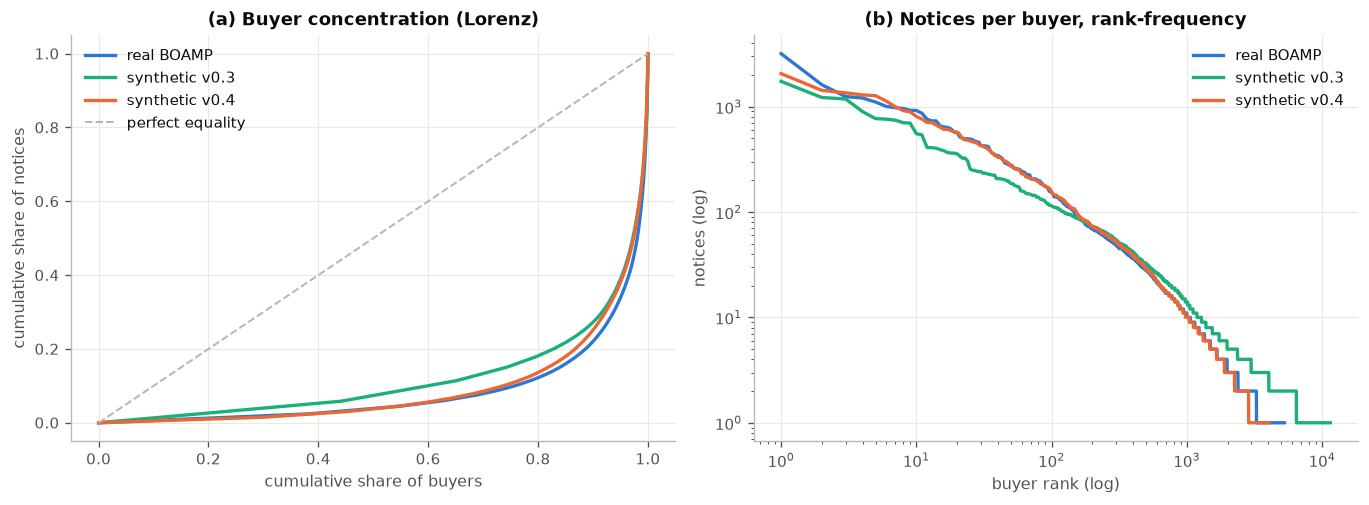

real BOAMP       keys/notice 0.0623  q50 2  q90 26  q99 260  max 3185
synthetic v0.3   keys/notice 0.1317  q50 2  q90 11  q99 105  max 1737
synthetic v0.4   keys/notice 0.0491  q50 3  q90 38  q99 328  max 2058


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

# (a) Lorenz curve of notices per buyer - concentration
ax = axes[0]
for label, df, color in DATASETS:
    counts = np.sort(buyer_keys(df).value_counts().to_numpy())
    cum = np.cumsum(counts) / counts.sum()
    x = np.arange(1, len(counts) + 1) / len(counts)
    ax.plot(x, cum, color=color, lw=2, label=label)
    gini = 1 - 2 * np.trapezoid(cum, x)
    print(f"{label:16} Gini of notices per buyer = {gini:.4f}")
ax.plot([0, 1], [0, 1], color=MUTED, lw=1.2, ls="--", label="perfect equality")
ax.set_title("(a) Buyer concentration (Lorenz)")
ax.set_xlabel("cumulative share of buyers"); ax.set_ylabel("cumulative share of notices")
ax.legend(loc="upper left")

# (b) rank-frequency on log-log - the tail shape v0.4 set out to fix
ax = axes[1]
for label, df, color in DATASETS:
    c = buyer_keys(df).value_counts().to_numpy()
    ax.plot(np.arange(1, len(c) + 1), c, color=color, lw=2, label=label)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("(b) Notices per buyer, rank-frequency")
ax.set_xlabel("buyer rank (log)"); ax.set_ylabel("notices (log)"); ax.legend()

finish(fig, "02_buyer_structure")
plt.show()

for label, df, _c in DATASETS:
    k = buyer_keys(df)
    q = k.value_counts()
    print(f"{label:16} keys/notice {k.nunique()/len(df):.4f}  "
          f"q50 {q.median():.0f}  q90 {q.quantile(.9):.0f}  q99 {q.quantile(.99):.0f}  max {q.max():.0f}")

### What the buyer plots show

The Lorenz curves are close — the synthetic corpus reproduces the *shape* of
real buyer concentration, which v0.3 did not (its needs-per-buyer Gini had
collapsed from ~0.8 to ~0.34, erasing the high-activity tail that creates dense
candidate neighbourhoods).

**But the level is still off.** Real BOAMP has 0.0623 distinct buyer keys per
notice; synthetic produces 0.0491 — about **21% too few** distinct buyers for the
same corpus size, so the average synthetic buyer holds more notices than a real
one. The quantiles show it directly: notices per buyer q50 2 → 3 and q90 26 → 38.
This is a *known, unresolved* v0.4 warning
(`buyer_activity / observed_keys_per_notice`, relative error 0.274 against a 0.2
tolerance). v0.4 halved the v0.3 error but did not close it.

The practical consequence is in section 6: more notices per buyer means more
candidates per source, which makes the synthetic linkage problem more crowded
than the real one.

## 4. CPV codes — the benchmark's most serious defect

`s_cpv` carries 0.30 of the composite score, and its ladder rewards *exact* code
agreement at 1.0 versus 0.2 for a division-only match. So the distribution of
codes within a division is not cosmetic — it directly sets how much evidence an
exact match represents.

Rank-frequency on log-log is the right form: it shows how often codes are reused,
which is exactly the property in question.

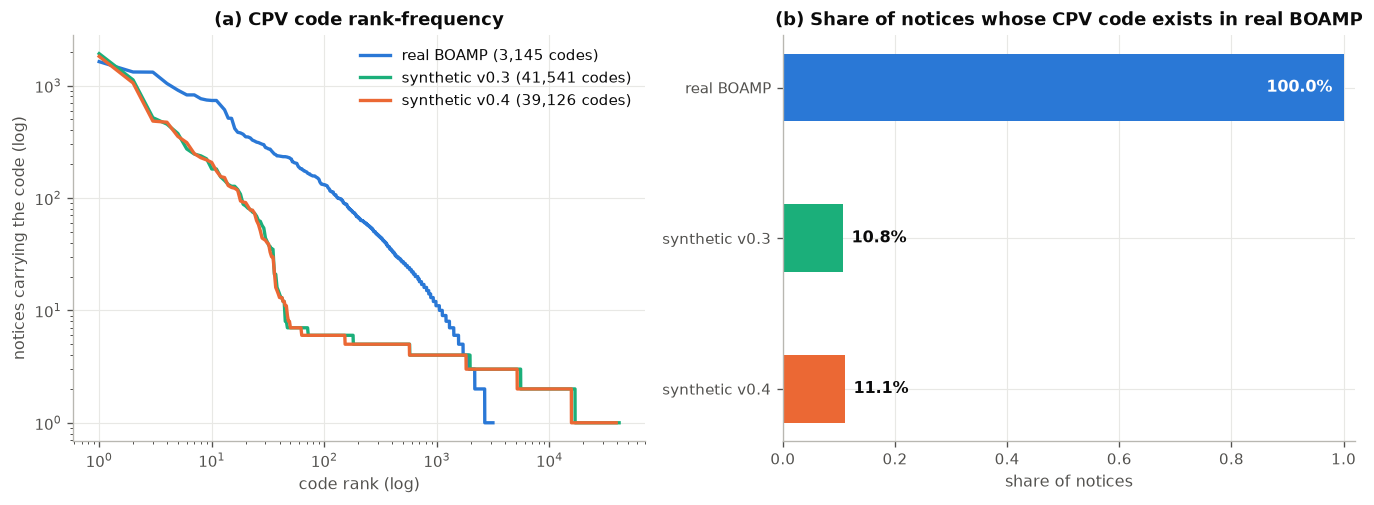

real BOAMP       distinct  3,145  notices/code   22.3  in real support 100.00%  ends '000'  64.1%
synthetic v0.3   distinct 41,541  notices/code    1.8  in real support  10.76%  ends '000'  16.5%
synthetic v0.4   distinct 39,126  notices/code    1.8  in real support  11.11%  ends '000'  16.7%


In [6]:
real_cpv = norm_cpv(real["cpv_clean"])
real_support = set(real_cpv.unique())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

# (a) rank-frequency of CPV codes - the defect in one picture
ax = axes[0]
for label, df, color in DATASETS:
    s = norm_cpv(df["cpv_clean"])
    c = s.value_counts().to_numpy()
    ax.plot(np.arange(1, len(c) + 1), c, color=color, lw=2, label=f"{label} ({len(c):,} codes)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_title("(a) CPV code rank-frequency")
ax.set_xlabel("code rank (log)"); ax.set_ylabel("notices carrying the code (log)"); ax.legend()

# (b) how much of each corpus uses a code that exists in real BOAMP
ax = axes[1]
labels, vals, colors = [], [], []
for label, df, color in DATASETS:
    labels.append(label)
    vals.append(norm_cpv(df["cpv_clean"]).isin(real_support).mean()); colors.append(color)
bars = ax.barh(labels, vals, 0.45, color=colors)
for b, v in zip(bars, vals):
    # short bars cannot hold an inside label without colliding with the tick text
    if v > 0.25:
        ax.text(v - 0.02, b.get_y() + b.get_height()/2, f"{v:.1%}",
                va="center", ha="right", color="white", fontweight="bold")
    else:
        ax.text(v + 0.015, b.get_y() + b.get_height()/2, f"{v:.1%}",
                va="center", ha="left", color=INK, fontweight="bold")
ax.set_xlim(0, 1.02); ax.invert_yaxis()
ax.set_title("(b) Share of notices whose CPV code exists in real BOAMP")
ax.set_xlabel("share of notices")

finish(fig, "03_cpv_support")
plt.show()

for label, df, _c in DATASETS:
    s = norm_cpv(df["cpv_clean"])
    print(f"{label:16} distinct {s.nunique():>6,}  notices/code {len(s)/s.nunique():>6.1f}  "
          f"in real support {s.isin(real_support).mean():>7.2%}  "
          f"ends '000' {s.str.endswith('000').mean():>6.1%}")

### What the CPV plots show — and why it invalidates a ranking claim

Panel (a) is the clearest single picture of a defect in this project. The real
curve is a short, steep distribution over ~3,145 codes reused an average of 22
times each. The synthetic curve is a long, flat shelf over ~39,000 codes reused
under twice each.

The generator drew `division + six random digits`. Codes like `71720593` and
`63197746` are not CPV codes; they exist nowhere in the standard. Panel (b) makes
the consequence concrete: **only about 11% of synthetic notices carry a code that
appears anywhere in the real corpus**, against 100% by definition for real.

The reason this matters for algorithm evaluation, rather than just realism:
because invented codes are near-unique, an exact CPV agreement between two
synthetic notices almost only happens between notices *of the same latent need*.
`s_cpv` therefore behaves as a near-oracle feature — it leaks the truth label
into an observable input.

Measured consequence (`reports/tables/real_linkage_freeze/cpv_anomaly_ablation.csv`):
collapsing `s_cpv` to division-only drops gradient boosting's end-to-end F1 from
0.269 to 0.154 and turns a 16/16 rank-1 sweep into a three-way tie with logistic
regression and the transparent composite baseline. That ablation is an **upper
bound** on the artifact — it also strips the sub-division signal that genuinely
exists in real BOAMP, where 4.70% of candidate pairs share an exact code — but it
is enough to establish that **no algorithm ranking may be quoted from v0.4
without correcting CPV generation**.

## 5. Contract description text

`s_text` carries the largest score weight (0.35), and it is computed from the
`objet_clean` field. Two properties matter: how long the descriptions are, and
how often the same wording repeats — because repeated administrative boilerplate
across unrelated contracts is what creates false text similarity.

Length is a distribution question, so ECDF; the duplication rates are two scalars
per corpus, so bars.

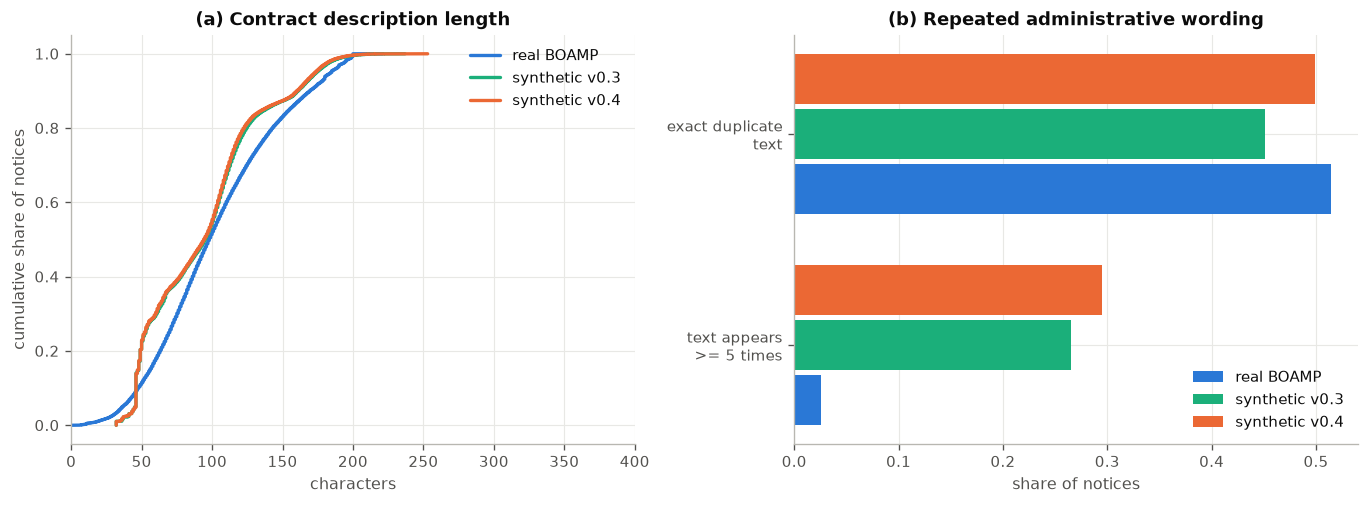

real BOAMP       length p50    98  p75   133  tokens p50   15  exact-dup 51.4%


synthetic v0.3   length p50    95  p75   118  tokens p50   14  exact-dup 45.1%


synthetic v0.4   length p50    94  p75   116  tokens p50   14  exact-dup 49.9%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

# (a) text length ECDF - distribution comparison, so ECDF not histogram
ax = axes[0]
for label, df, color in DATASETS:
    ecdf(ax, df["objet_clean"].fillna("").astype(str).str.len(), label, color)
ax.set_xlim(0, 400)
ax.set_title("(a) Contract description length")
ax.set_xlabel("characters"); ax.set_ylabel("cumulative share of notices"); ax.legend()

# (b) duplicate structure
ax = axes[1]
cats = ["exact duplicate\ntext", "text appears\n>= 5 times"]
series = []
for label, df, color in DATASETS:
    tt = df["objet_clean"].fillna("").astype(str)
    vc = tt.value_counts()
    series.append((label, [tt.duplicated(keep=False).mean(), tt.map(vc).ge(5).mean()], color))
grouped_barh(ax, cats, series, "(b) Repeated administrative wording", "share of notices")

finish(fig, "04_text")
plt.show()

for label, df, _c in DATASETS:
    tt = df["objet_clean"].fillna("").astype(str)
    print(f"{label:16} length p50 {tt.str.len().median():>5.0f}  p75 {tt.str.len().quantile(.75):>5.0f}  "
          f"tokens p50 {tt.str.split().str.len().median():>4.0f}  exact-dup {tt.duplicated(keep=False).mean():.1%}")

### What the text plots show

Length matches closely at the median (98 real vs 94 synthetic characters) and
drifts apart in the upper tail — real p75 is 133 against 117 synthetic, a
*known, unresolved* v0.4 warning (`marginals / text_length / q75_relative_error`,
0.128 against a 0.1 tolerance). The synthetic corpus produces slightly shorter
descriptions than reality at the long end.

Exact-duplicate share is reproduced well (~51% real vs ~50% synthetic). That is a
deliberate v0.2 correction: real BOAMP's high literal-duplication rate is driven
by shared official boilerplate reused across *unrelated* buyers, and the generator
models that explicitly rather than letting it emerge.

The caution is that matching the *rate* of duplication does not mean matching
*which* pairs are similar. Section 6 shows that when the same text is scored over
candidate pairs, the synthetic and real distributions come apart sharply.

## 6. The features the linkage rule actually scores

Sections 2–5 compared the corpora. This section compares what the *linker sees*:
the four sub-scores computed over candidate pairs. If these distributions differ,
a model trained on synthetic data cannot be applied to real data, regardless of
how well the corpora match on composition.

ECDFs, because the question is distributional and the pair counts differ by an
order of magnitude.

real BOAMP         10,862 candidate pairs from  2,005 sources
synthetic v0.3      8,920 candidate pairs from  2,259 sources
synthetic v0.4      8,380 candidate pairs from  1,794 sources


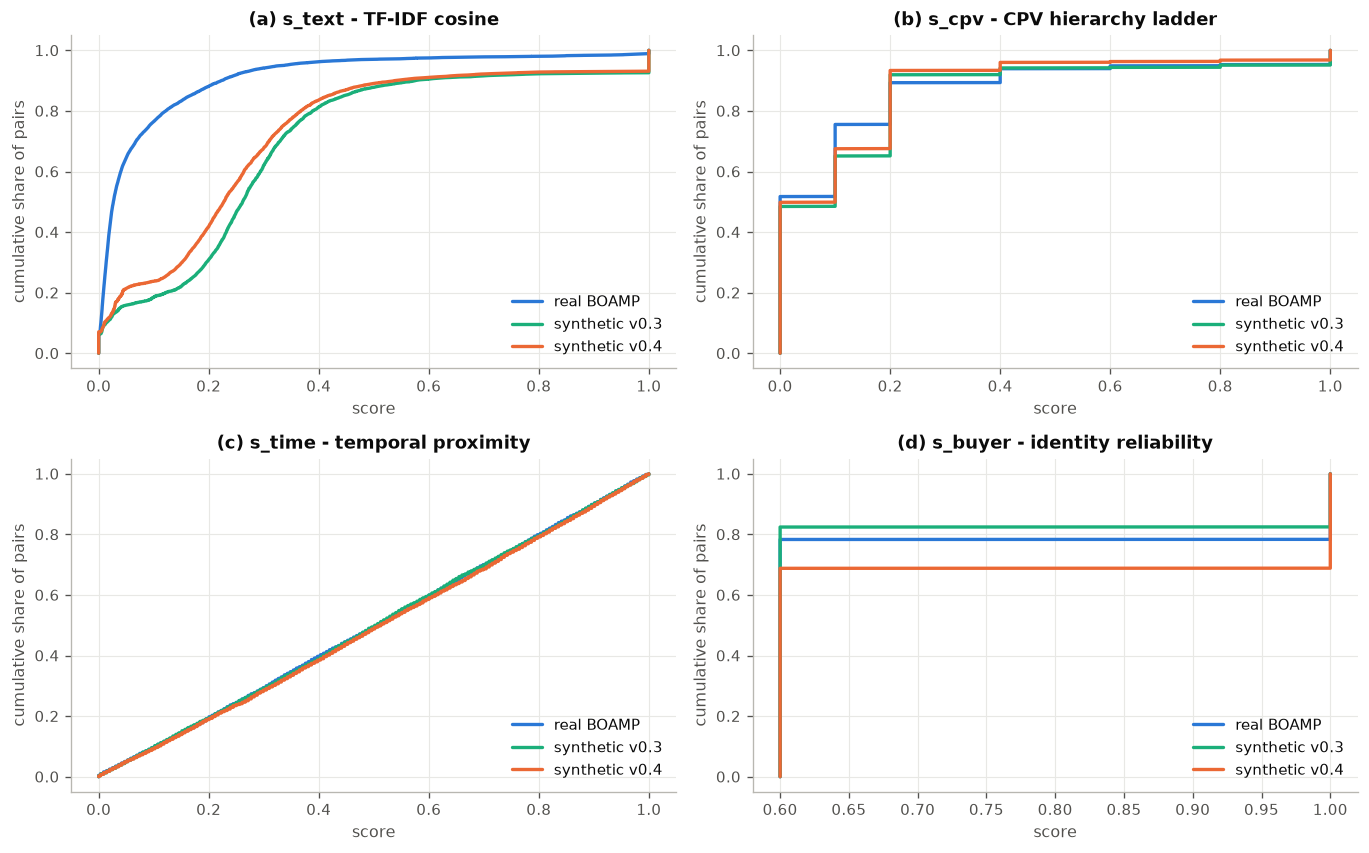

,real BOAMP,synthetic v0.3,synthetic v0.4,v0.3 / real,v0.4 / real
s_text,0.0868,0.3006,0.2709,3.4644,3.1212
s_cpv,0.1259,0.1352,0.1178,1.0739,0.9357
s_time,0.5036,0.5041,0.5104,1.0009,1.0135
s_buyer,0.6867,0.6703,0.7248,0.9761,1.0555


In [8]:
from boamp.config import load_config
from boamp.linkage.candidates import generate_pairs_single_key
from boamp.synthetic.validation_framework.difficulty import scoped_sources
from boamp.synthetic.validation_framework.loaders import load_benchmark_data

cfg = load_config(ROOT)

real_pairs = pd.read_csv(ROOT / "data/processed/boamp_only/boamp_only_candidate_pairs.csv")

def syn_pairs_for(version, world="001"):
    d = load_benchmark_data(ROOT, version, "central_provisional", world, world)
    pairs, _w = generate_pairs_single_key(scoped_sources(d), cfg, verbose=False)
    return pairs

syn_pairs = syn_pairs_for(V4_VERSION)
v3_pairs = syn_pairs_for(V3_VERSION)

PAIR_SETS = [("real BOAMP", real_pairs, REAL), ("synthetic v0.3", v3_pairs, V3),
             ("synthetic v0.4", syn_pairs, V4)]
for label, pr, _c in PAIR_SETS:
    print(f"{label:16} {len(pr):>8,} candidate pairs from {pr.source_notice_id.nunique():>6,} sources")

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.2))
for ax, feat, title in zip(
    axes.ravel(),
    ["s_text", "s_cpv", "s_time", "s_buyer"],
    ["(a) s_text - TF-IDF cosine", "(b) s_cpv - CPV hierarchy ladder",
     "(c) s_time - temporal proximity", "(d) s_buyer - identity reliability"],
):
    for label, pr, color in PAIR_SETS:
        ecdf(ax, pr[feat], label, color)
    ax.set_title(title); ax.set_xlabel("score"); ax.set_ylabel("cumulative share of pairs")
    ax.legend(loc="lower right")
finish(fig, "05_linkage_features")
plt.show()

feats = ["s_text", "s_cpv", "s_time", "s_buyer"]
comp = pd.DataFrame({lab: [pr[f].mean() for f in feats] for lab, pr, _c in PAIR_SETS},
                    index=feats)
comp["v0.3 / real"] = comp["synthetic v0.3"] / comp["real BOAMP"]
comp["v0.4 / real"] = comp["synthetic v0.4"] / comp["real BOAMP"]
comp.round(4)

### What the feature plots show — this is why no trained model reaches real BOAMP

Three of the four features line up well. `s_time`, `s_buyer` and `s_cpv` sit
within roughly 0.9–1.0× of their real means.

**`s_text` does not.** On this world its synthetic mean is **3.12×** the real mean
(0.271 vs 0.087), and the ECDF gap is visible across the whole range. Real
contract descriptions repeat far less than the generator's templated text. Pooled
over the four fit worlds the ratio is 3.56× — either way, the same order of
distortion in the feature carrying the largest score weight (0.35).

The consequence is decisive and was measured directly
(`synthetic_to_real_transfer_test.csv`). A gradient-boosting linker trained on
synthetic worlds, applied to real candidate pairs at its synthetic-calibrated
threshold, accepts **333 links (9.9%)** where the transparent composite rule
accepts **1,003 (29.7%)**. It learned to rely on a text signal three and a half
times stronger than reality provides, so it under-accepts by roughly a factor of
three.

Since real BOAMP has no labels to retrain on, this is not a tuning problem — it
is the reason the frozen real configuration uses the transparent composite rule
and **no supervised model is applied to real data at all**.

## 7. Candidate environment

How many candidates each source has to choose between is the difficulty of the
linkage problem. It is also where the synthetic benchmark is least stable.

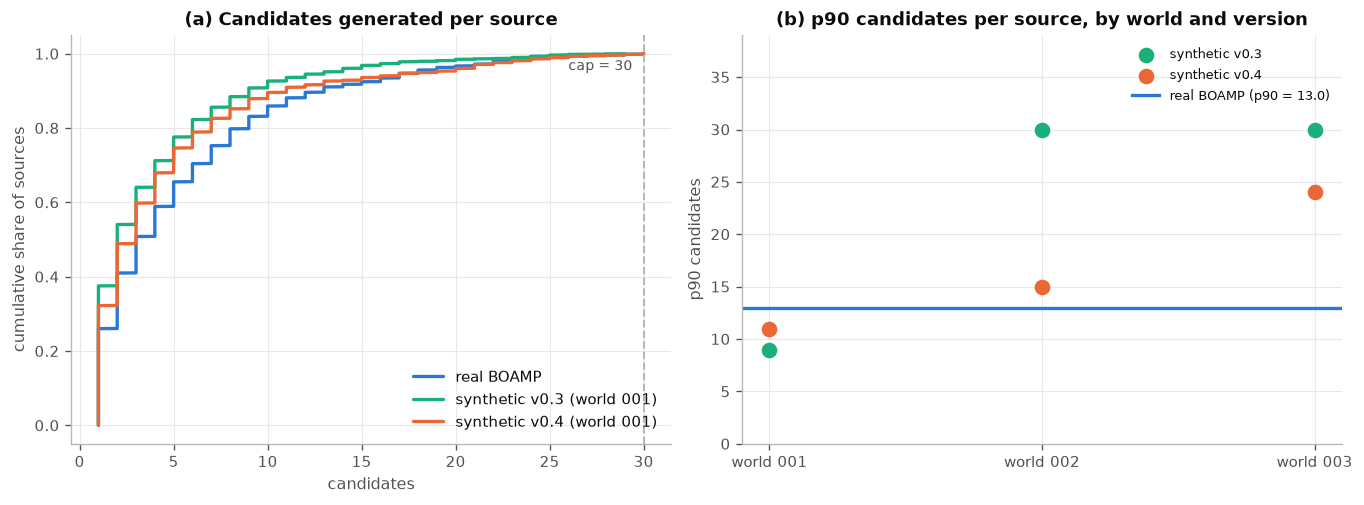

real  p90 candidates/source = 13.0
synthetic v0.3 p90 by world = 9.0, 30.0, 30.0   (mean 23.0)
synthetic v0.4 p90 by world = 11.0, 15.0, 24.0   (mean 16.7)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

# (a) candidates per source - ECDF
ax = axes[0]
for label, pr, color in PAIR_SETS:
    suffix = "" if label.startswith("real") else " (world 001)"
    ecdf(ax, pr.groupby("source_notice_id").size(), label + suffix, color)
ax.axvline(cfg.pipeline.candidates.max_candidates_per_source, color=MUTED, lw=1.2, ls="--")
ax.text(cfg.pipeline.candidates.max_candidates_per_source - 0.6, 0.985, "cap = 30",
        ha="right", va="top", color=INK2, fontsize=8.5)
ax.set_title("(a) Candidates generated per source")
ax.set_xlabel("candidates"); ax.set_ylabel("cumulative share of sources"); ax.legend(loc="lower right")

# (b) world-to-world instability of the candidate environment
ax = axes[1]
p90 = {}
for label, version, color in [("synthetic v0.3", V3_VERSION, V3), ("synthetic v0.4", V4_VERSION, V4)]:
    vals = [syn_pairs_for(version, w).groupby("source_notice_id").size().quantile(.9)
            for w in SYN_WORLDS]
    p90[label] = vals
    ax.scatter(range(1, len(vals) + 1), vals, s=70, color=color, zorder=3, label=label)
real_p90 = real_pairs.groupby("source_notice_id").size().quantile(.9)
ax.axhline(real_p90, color=REAL, lw=2, label=f"real BOAMP (p90 = {real_p90:.1f})")
ax.set_xticks(range(1, len(SYN_WORLDS) + 1)); ax.set_xticklabels([f"world {w}" for w in SYN_WORLDS])
ax.set_title("(b) p90 candidates per source, by world and version")
ax.set_ylabel("p90 candidates")
ax.set_ylim(0, max(max(v) for v in p90.values()) * 1.3); ax.legend(fontsize=8)

finish(fig, "06_candidate_environment")
plt.show()

print(f"real  p90 candidates/source = {real_p90:.1f}")
for label, vals in p90.items():
    print(f"{label} p90 by world = " + ", ".join(f"{v:.1f}" for v in vals)
          + f"   (mean {np.mean(vals):.1f})")

### What the candidate plots show

Panel (a) compares real BOAMP against **world 001 specifically**, and on this
world the synthetic environment is slightly *sparser* than real (p90 of 11
against 13). That is not the general picture, which is the point of panel (b).

**Panel (b) is a warning about the validation framework itself.** These are worlds
from the *same configuration*, differing only in random seed. v0.4 runs **11, 15,
24** against a real value of 13; v0.3 runs **9, 30, 30**. In both versions the
spread across seeds is larger than the gap to real, and v0.3 is the more extreme
case — two of its three worlds sit at the 30-candidate cap.

Averaged over worlds both versions are denser than real (mean p90 23.0 for v0.3,
16.7 for v0.4, against 13.0), so v0.4 improved this too — but no *single* world
supports that statement, and world 001 points the other way in both versions.

This matters because the validation framework evaluates
`world_001` alone (`validation_manifest.json` records `world: 001` for every
released version).

That single-world dependence has a demonstrated consequence: running the same
benchmark's validation on `world_002` instead of `world_001` moves
`candidate_environment` from FAIL to PASS and the overall status from FAIL to
PASS_WITH_WARNINGS. **Any headline gate status in this repository should be read
as a one-world draw, not a property of the benchmark.** Across ten worlds the
p90 candidate count is over-produced against real BOAMP in every version tested,
which single-world validation was hiding.

## 8. Real BOAMP survival evidence

Everything above is about whether the datasets are trustworthy. This section is
the actual analysis output: the time-to-renewal curves, under all three frozen
decision rules.

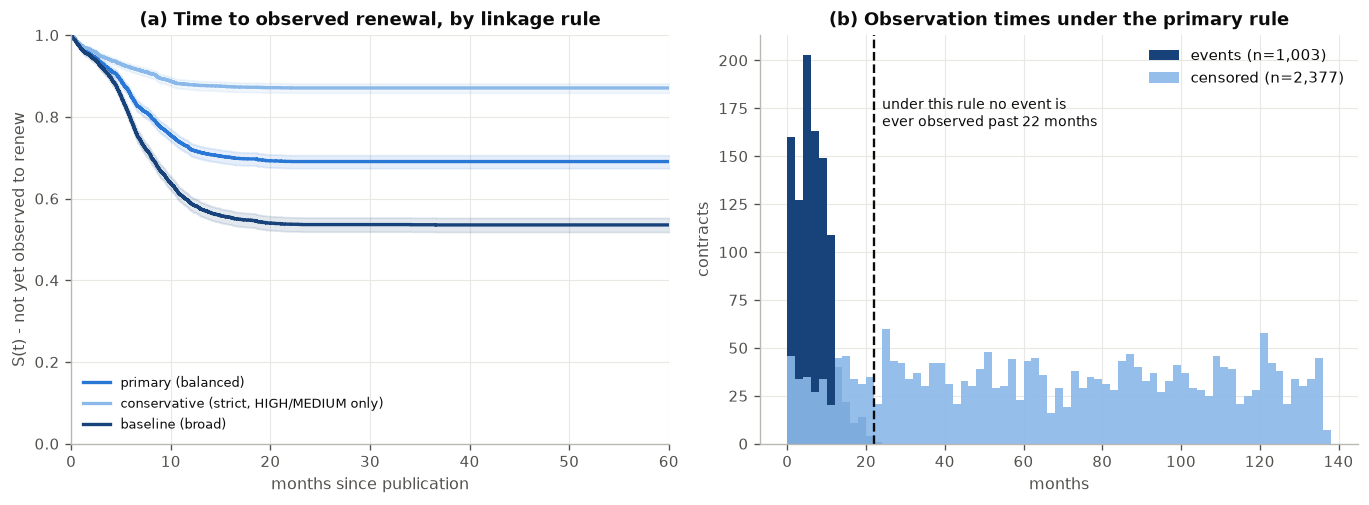

primary (balanced)                         events  1003  rate 0.297  max event time   22.1m
conservative (strict, HIGH/MEDIUM only)    events   422  rate 0.125  max event time   22.1m
baseline (broad)                           events  1504  rate 0.445  max event time   36.6m


In [10]:
from lifelines import KaplanMeierFitter

sv = {
    "primary (balanced)": pd.read_csv(ROOT / "data/processed/boamp_only/boamp_only_survival.csv"),
    "conservative (strict, HIGH/MEDIUM only)":
        pd.read_csv(ROOT / "data/processed/boamp_only/boamp_only_survival_conservative_strict.csv"),
    "baseline (broad)": pd.read_csv(ROOT / "data/processed/boamp_only/boamp_only_survival_broad.csv"),
}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

# (a) KM by decision rule
ax = axes[0]
for (label, d), color in zip(sv.items(), [RULE_RAMP[1], RULE_RAMP[0], RULE_RAMP[2]]):
    kmf = KaplanMeierFitter().fit(d["time_to_event_or_censor_months"], d["event"])
    kmf.plot_survival_function(ax=ax, color=color, lw=2, ci_alpha=0.12, label=label)
ax.set_xlim(0, 60); ax.set_ylim(0, 1)
ax.set_title("(a) Time to observed renewal, by linkage rule")
ax.set_xlabel("months since publication"); ax.set_ylabel("S(t) - not yet observed to renew")
ax.legend(loc="lower left", fontsize=8)

# (b) the observable-event ceiling
ax = axes[1]
prim = sv["primary (balanced)"]
ev = prim.loc[prim.event == 1, "time_to_event_or_censor_months"]
cen = prim.loc[prim.event == 0, "time_to_event_or_censor_months"]
ax.hist(ev, bins=np.arange(0, 140, 2), color=RULE_RAMP[2], label=f"events (n={len(ev):,})")
ax.hist(cen, bins=np.arange(0, 140, 2), color=RULE_RAMP[0], alpha=0.9,
        label=f"censored (n={len(cen):,})")
ax.axvline(ev.max(), color=INK, lw=1.4, ls="--")
ax.text(ev.max() + 2, ax.get_ylim()[1] * 0.85,
        f"under this rule no event is\never observed past {ev.max():.0f} months",
        color=INK, fontsize=8.5, va="top")
ax.set_title("(b) Observation times under the primary rule")
ax.set_xlabel("months"); ax.set_ylabel("contracts"); ax.legend()

finish(fig, "07_survival")
plt.show()

for label, d in sv.items():
    e = d.loc[d.event == 1, "time_to_event_or_censor_months"]
    print(f"{label:42} events {int(d.event.sum()):>5}  rate {d.event.mean():.3f}  "
          f"max event time {e.max():>6.1f}m")

### What the survival plots show

**Panel (a): the linkage rule moves the answer more than any covariate does.**
The event rate runs 12.5% (conservative) → 29.7% (primary) → 44.5% (broad), and
RMST(60m) runs 52.9 → 43.5 → 35.4 months. That ~50% swing is larger than any
hazard ratio in the Cox model. Median survival is not reached under any rule, so
"median time to renewal" is not estimable from this data.

**Panel (b) is the most important caveat in the whole analysis.** Under the
primary rule, event times stop dead at **22.1 months** — not "taper off", *stop*.
Zero events are observed beyond 24 months, which is why S(24m) and S(36m) are
identical to six decimal places (0.690794).

That is not a fact about procurement. It is the candidate window: successors are
only sought within ±6 months of the estimated end date, and the median declared
duration is 6 months, so the detector is structurally blind past roughly 22
months. The flat right-hand tail of the KM curve is an artifact of the
instrument, and reading "69% have still not renewed at 36 months" as a
substantive finding would be a misreading.

**The ceiling is rule-dependent, which confirms the mechanism.** The conservative
rule shares the 22.1-month bound, but the broad rule reaches **36.6 months** — a
lower acceptance threshold admits rank-1 candidates further from the expected end
date. So the visible horizon is set by the linkage configuration, not by the
data. Any statement about long-horizon renewal is a statement about the detector.

## 9. Who could ever have been linked

The event indicator is emphatically not missing at random. This section shows the
two gradients that govern it.

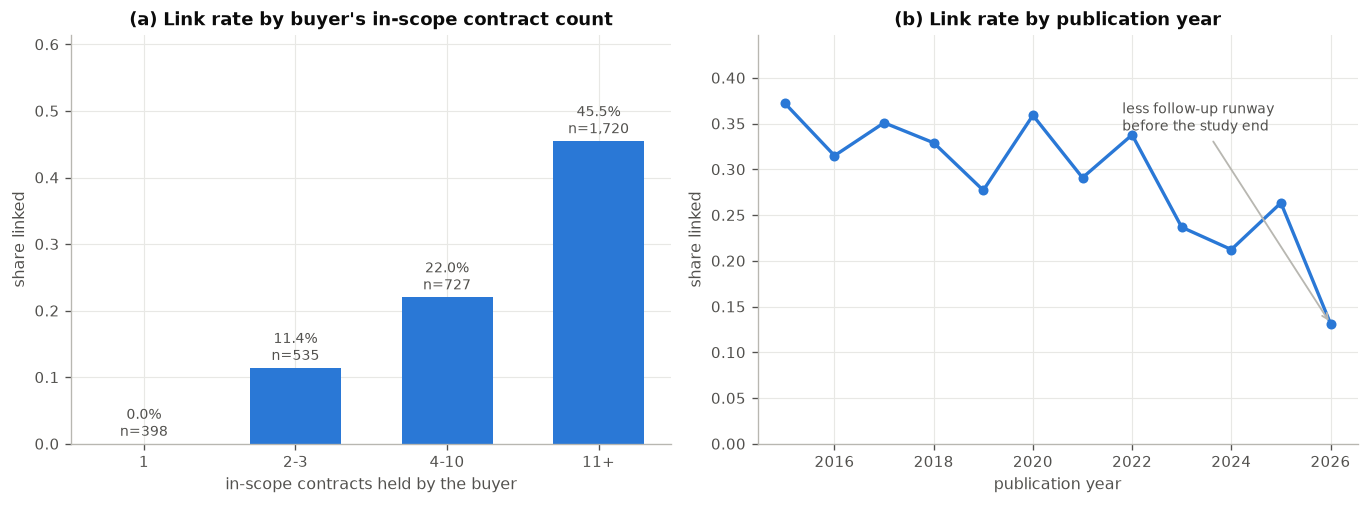

                rate     n
activity_bin              
1             0.0000   398
2-3           0.1140   535
4-10          0.2201   727
11+           0.4547  1720

sources with no candidate at all : 1,375 of 3,380 (40.7%)


In [11]:
src = pd.read_csv(ROOT / "data/processed/boamp_only/boamp_only_sources.csv")
prim = sv["primary (balanced)"]
linked = set(prim.loc[prim.event == 1, "notice_id"])
src["linked"] = src["notice_id"].isin(linked)
src["publication_year"] = pd.to_datetime(src["publication_date"]).dt.year
act = src.groupby("buyer_key")["notice_id"].transform("count")
src["activity_bin"] = pd.cut(act, [0, 1, 3, 10, 1e9], labels=["1", "2-3", "4-10", "11+"])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))

# (a) link rate by buyer activity - the structural driver
ax = axes[0]
g = src.groupby("activity_bin", observed=True).agg(rate=("linked", "mean"), n=("linked", "size"))
bars = ax.bar(g.index.astype(str), g["rate"], 0.6, color=REAL)
for b, (r, n) in zip(bars, g.itertuples(index=False)):
    ax.text(b.get_x() + b.get_width()/2, r + 0.012, f"{r:.1%}\nn={n:,}",
            ha="center", fontsize=8.5, color=INK2)
ax.set_ylim(0, g["rate"].max() * 1.35)
ax.set_title("(a) Link rate by buyer's in-scope contract count")
ax.set_xlabel("in-scope contracts held by the buyer"); ax.set_ylabel("share linked")

# (b) link rate by year - confounded with follow-up runway
ax = axes[1]
gy = src.groupby("publication_year").agg(rate=("linked", "mean"), n=("linked", "size"))
ax.plot(gy.index, gy["rate"], color=REAL, lw=2, marker="o", ms=5)
ax.set_title("(b) Link rate by publication year")
ax.set_xlabel("publication year"); ax.set_ylabel("share linked")
ax.set_ylim(0, gy["rate"].max() * 1.2)
ax.annotate("less follow-up runway\nbefore the study end",
            xy=(gy.index[-1], gy["rate"].iloc[-1]), xytext=(gy.index[-1] - 4.2, gy["rate"].max() * 0.92),
            fontsize=8.5, color=INK2,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.1))

finish(fig, "08_selection_bias")
plt.show()

print(g.assign(rate=lambda d: d["rate"].round(4)).to_string())
print()
print(f"sources with no candidate at all : "
      f"{len(src) - real_pairs.source_notice_id.nunique():,} of {len(src):,} "
      f"({1 - real_pairs.source_notice_id.nunique()/len(src):.1%})")

### What the bias plots show

**Panel (a): observed renewal is substantially a measure of buyer publication
volume.** Buyers holding a single in-scope contract link at 0.0% — not "rarely",
*never*, because there is no second notice of theirs to link to. The rate then
climbs monotonically to ~45% for buyers holding 11 or more. Roughly 400 sources
are censored by arithmetic rather than by evidence, and 1,375 of 3,380 (40.7%)
generate no candidate at all.

**Panel (b): the year gradient is mostly the observation window closing.** The
link rate falls from ~37% in 2015 to ~13% in 2026 because recent contracts have
less follow-up runway before the 2026-07-13 study end. This is why any trend
claim must be made on the survival scale with year strata — **the raw link-rate
trend is not evidence that renewals are becoming rarer**, and quoting it as such
would be the single easiest mistake to make with this dataset.

## 10. What changed between v0.3 and v0.4

v0.4 revised three observable mechanisms: buyer publication timing, buyer
population scale with buyer-persistent identifier visibility, and buyer-name
alias structure. This table scores both versions against the real corpus on the
quantities those mechanisms touch, plus the ones they did not, so improvement and
non-improvement are visible together.

In [12]:
def profile(df):
    k = buyer_keys(df); c = norm_cpv(df["cpv_clean"]); tt = df["objet_clean"].fillna("").astype(str)
    q = k.value_counts()
    counts = np.sort(q.to_numpy()); cum = np.cumsum(counts) / counts.sum()
    x = np.arange(1, len(counts) + 1) / len(counts)
    return {
        "buyer keys per notice": k.nunique() / len(df),
        "buyer Gini": 1 - 2 * np.trapezoid(cum, x),
        "q90 notices per buyer": q.quantile(.9),
        "distinct CPV codes": c.nunique(),
        "notices per CPV code": len(c) / c.nunique(),
        "CPV in real support": c.isin(real_support).mean(),
        "SIRET present": df["buyer_siret_raw"].notna().mean() if "buyer_siret_raw" in df else np.nan,
        "text length p75": tt.str.len().quantile(.75),
        "exact duplicate text": tt.duplicated(keep=False).mean(),
    }

prof = pd.DataFrame({lab: profile(df) for lab, df, _c in DATASETS})

def closer(row):
    """Which version sits nearer the real value on this quantity."""
    r = row["real BOAMP"]
    if not np.isfinite(r) or r == 0:
        return "-"
    d3, d4 = abs(row["synthetic v0.3"] - r) / abs(r), abs(row["synthetic v0.4"] - r) / abs(r)
    if abs(d3 - d4) < 0.02:
        return "unchanged"
    return "v0.4 closer" if d4 < d3 else "v0.3 closer"

prof["v0.3 rel. error"] = ((prof["synthetic v0.3"] - prof["real BOAMP"]).abs()
                           / prof["real BOAMP"].abs())
prof["v0.4 rel. error"] = ((prof["synthetic v0.4"] - prof["real BOAMP"]).abs()
                           / prof["real BOAMP"].abs())
prof["verdict"] = prof.apply(closer, axis=1)
prof.round(4)

,real BOAMP,synthetic v0.3,synthetic v0.4,v0.3 rel. error,v0.4 rel. error,verdict
buyer keys per notice,0.0623,0.1317,0.0491,1.1159,0.2109,v0.4 closer
buyer Gini,0.8316,0.7637,0.8181,0.0817,0.0163,v0.4 closer
q90 notices per buyer,26.3000,11.0000,38.0000,0.5817,0.4449,v0.4 closer
distinct CPV codes,3145.0000,41541.0000,39126.0000,12.2086,11.4407,v0.4 closer
notices per CPV code,22.3164,1.7865,1.7833,0.9199,0.9201,unchanged
CPV in real support,1.0000,0.1076,0.1111,0.8924,0.8889,unchanged
SIRET present,0.2722,0.3133,0.2960,0.1510,0.0874,v0.4 closer
text length p75,133.0000,118.0000,116.0000,0.1128,0.1278,unchanged
exact duplicate text,0.5143,0.4514,0.4988,0.1224,0.0302,v0.4 closer


### What the delta table shows

**The buyer-population correction worked, and overshot.** v0.3 produced 0.132
buyer keys per notice against a real 0.062 — **2.1x too many**, which is the defect
the v0.4 report describes as "roughly twice as many observed buyer keys per
notice". v0.4 moved it to 0.049, which is now **21% too few**. The relative error
fell from about 111% to about 21%, so this is a real and large improvement, but
the mechanism did not land on the target — it crossed it.

The consequence is visible in the tail: q90 notices per buyer runs 11 (v0.3) → 26
(real) → 38 (v0.4). v0.3's buyers were too numerous and each too quiet; v0.4's are
too few and each too busy. Buyer concentration improved markedly on the summary
measure — Gini 0.764 → 0.818 against a real 0.832.

**Identifier visibility improved.** SIRET presence moved from 0.313 to 0.296
against a real 0.272. v0.3's excess was partly a publication-year composition
artifact, since SIRET presence rises from roughly 7% in 2015 to 57% in 2022, and
fixing the year mix fixed part of the identifier gap.

**Repeated wording improved substantially**: exact-duplicate share 0.451 → 0.499
against a real 0.514.

**CPV was not touched, and is effectively identical in both versions.** Notices
per code 1.79 → 1.78 and share in real support 10.8% → 11.1% both come back
`unchanged`. The distinct-code count is nominally scored `v0.4 closer` (41.5k →
39.1k), but read that label with care: the relative error only moves from 12.2 to
11.4 — both versions are more than **eleven times** the real value, so the
"improvement" is noise on a quantity that fails outright either way. The point is
that this defect is **not a v0.4 regression**; it is a long-standing property of
the generator that neither released version addresses.

**Text length in the upper tail is the one quantity where v0.3 is nominally
nearer**: p75 118 vs 116 against a real 133, i.e. relative error 11.3% → 12.8%.
That gap is inside the table's 2-point tolerance, so it scores `unchanged` — worth
noting as the one non-improvement, not worth calling a regression.

**Reading the verdict column.** It compares relative error against real and calls
anything within 2 percentage points `unchanged`. It says which version is *nearer*,
never whether either is *acceptable* — CPV is scored `v0.4 closer` on one row while
failing the gate in both versions.

## 11. Evidence summary

In [13]:
def fmt(x, pct=False, n=0):
    return f"{x:.1%}" if pct else (f"{x:,.{n}f}")

evidence = pd.DataFrame([
    ("corpus size", f"{len(real):,}", f"{len(v3):,}", f"{len(syn):,}", "comparable by design"),
    ("buyer keys per notice",
     fmt(buyer_keys(real).nunique()/len(real), n=4),
     fmt(buyer_keys(v3).nunique()/len(v3), n=4),
     fmt(buyer_keys(syn).nunique()/len(syn), n=4),
     "v0.3 2.1x too many; v0.4 21% too few"),
    ("buyer Gini", fmt(prof.loc["buyer Gini", "real BOAMP"], n=3),
     fmt(prof.loc["buyer Gini", "synthetic v0.3"], n=3),
     fmt(prof.loc["buyer Gini", "synthetic v0.4"], n=3), "v0.4 close"),
    ("distinct CPV codes", f"{real_cpv.nunique():,}",
     f"{norm_cpv(v3['cpv_clean']).nunique():,}",
     f"{norm_cpv(syn['cpv_clean']).nunique():,}", "FAILS in both - invented codes"),
    ("CPV codes in real support", "100%",
     fmt(norm_cpv(v3['cpv_clean']).isin(real_support).mean(), pct=True),
     fmt(norm_cpv(syn['cpv_clean']).isin(real_support).mean(), pct=True),
     "FAILS in both - unchanged by v0.4"),
    ("text length p75",
     fmt(real['objet_clean'].fillna('').str.len().quantile(.75)),
     fmt(v3['objet_clean'].fillna('').str.len().quantile(.75)),
     fmt(syn['objet_clean'].fillna('').str.len().quantile(.75)), "both short; v0.3 marginally closer"),
    ("exact duplicate text",
     fmt(real['objet_clean'].fillna('').astype(str).duplicated(keep=False).mean(), pct=True),
     fmt(v3['objet_clean'].fillna('').astype(str).duplicated(keep=False).mean(), pct=True),
     fmt(syn['objet_clean'].fillna('').astype(str).duplicated(keep=False).mean(), pct=True),
     "v0.4 close"),
    ("mean s_text on candidate pairs", fmt(real_pairs.s_text.mean(), n=3),
     fmt(v3_pairs.s_text.mean(), n=3), fmt(syn_pairs.s_text.mean(), n=3),
     "FAILS in both - synthetic too easy"),
    ("p90 candidates/source", fmt(real_p90, n=1),
     fmt(np.mean(p90["synthetic v0.3"]), n=1), fmt(np.mean(p90["synthetic v0.4"]), n=1),
     "over-produced, wide across seeds"),
], columns=["quantity", "real BOAMP", "synthetic v0.3", "synthetic v0.4", "verdict"])
evidence

,quantity,real BOAMP,synthetic v0.3,synthetic v0.4,verdict
0,corpus size,"84,623","87,360","82,278",comparable by design
1,buyer keys per notice,0.0623,0.1317,0.0491,v0.3 2.1x too many; v0.4 21% too few
2,buyer Gini,0.832,0.764,0.818,v0.4 close
3,distinct CPV codes,"3,145","41,541","39,126",FAILS in both - invented codes
4,CPV codes in real support,100%,10.8%,11.1%,FAILS in both - unchanged by v0.4
5,text length p75,133,118,116,both short; v0.3 marginally closer
6,exact duplicate text,51.4%,45.1%,49.9%,v0.4 close
7,mean s_text on candidate pairs,0.087,0.301,0.271,FAILS in both - synthetic too easy
8,p90 candidates/source,13.0,23.0,16.7,"over-produced, wide across seeds"


## Takeaways

**Where the synthetic benchmark earns its keep.** Composition, calendar
structure, notice-type and schema mix, text length, and buyer *concentration
shape* all reproduce real BOAMP closely. For questions about how a linker behaves
under a BOAMP-like observed structure, it is a reasonable instrument.

**Three failures bound what may be claimed.**

1. **CPV codes are invented**, making exact-code agreement a near-oracle feature.
   No algorithm ranking may be quoted from v0.4 until this is corrected.
2. **Synthetic text is roughly 3.5× easier** on `s_text`, which blocks transfer of
   any trained model to real BOAMP. Combined with the absence of real labels, this
   is why the frozen real rule is the transparent composite.
3. **Candidate density is over-produced**, and the single-world validation design
   hides both this and its own instability.

**On the real side**, three structural facts qualify every survival number: no
event is observable past ~22 months, 40.7% of sources never generate a candidate,
and single-contract buyers can never produce an event. The 29.7% event rate is the
output of one decision rule among three spanning 12.5%–44.5% — it is not an
estimate of true renewal prevalence, and the linkage rule contributes more
uncertainty than any covariate in the model.

**The instrument that would resolve most of this** is the 100-case stratified
audit in `reports/tables/real_linkage_freeze/real_audit_sample_100.csv`, which
currently has zero completed labels.